# Modelado y Relaciones

Este notebook presenta analisis avanzados sobre los datos consolidados de rotacion incluyendo:
1. Analisis de sentimientos sobre respuestas
2. Correlaciones entre topics y variables organizacionales
3. Clustering de perfiles de respuesta
4. Grafos de relaciones entre variables

## 1. Configuracion del Entorno

In [1]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Entorno configurado correctamente")

Entorno configurado correctamente


## 2. Carga y Exploracion Inicial de Datos

In [ ]:
# Carga del dataset consolidado
df = pd.read_csv('../data/df_core_final.csv')

print(f"Dimensiones del dataset: {df.shape}")


Dimensiones del dataset: (5033, 161)


In [5]:
# Identificacion de columnas de topics
topic_cols = [col for col in df.columns if col.startswith(('P1_', 'P2_', 'P3_', 'P4_', 'P5_', 'P6_'))]
print(f"Total de columnas de topics identificadas: {len(topic_cols)}")
print(f"\nPrimeras 20 columnas de topics:")
for i, col in enumerate(topic_cols[:20], 1):
    print(f"{i}. {col}")

Total de columnas de topics identificadas: 120

Primeras 20 columnas de topics:
1. P1_n_0_compromiso_y_responsabilidad
2. P1_n_1_beneficios_y_valores_de_la_empresa
3. P1_n_2_prestaciones_y_sueldo
4. P1_n_3_buen_ambiente_laboral
5. P1_n_4_oportunidades_de_desarrollo_y_crecimiento
6. P1_n_5_satisfaccion_y_gusto_por_el_trabajo
7. P1_n_6_crecimiento_y_estabilidad_laboral
8. P1_n_7_estabilidad_y_seguridad_laboral
9. P1_n_8_identificacion_con_la_empresa_y_balance
10. P1_n_9_buen_trato_y_apoyo
11. P1_v_0_compromiso_y_lealtad
12. P1_v_1_oferta_de_prestaciones_de_la_empresa
13. P1_v_2_necesidad_de_un_trabajo_estable
14. P1_v_3_compensacion_y_condiciones_laborales
15. P1_v_4_satisfaccion_con_el_trabajo
16. P1_v_5_ambiente_y_desarrollo_laboral
17. P1_v_6_apoyo_de_la_empresa_a_colaboradores
18. P1_v_7_comodidad_y_beneficios_adicionales
19. P1_v_8_oportunidades_de_crecimiento_y_beneficios
20. P1_v_9_estabilidad_y_seguridad_laboral


In [6]:
# Identificacion de variables organizacionales
org_cols = ['escolaridad', 'tipo_rol', 'region', 'ciudad', 'empleador_legal', 
            'division', 'departamento', 'antiguedad_anois',
            'tamano_equipo', 'pct_ocupacion_equipo', 'grupos_salariales',
            'promedio_grupo_salarial', 'promedio_antiguedad_subordinados_anos']

org_cols_disponibles = [col for col in org_cols if col in df.columns]
print(f"Variables organizacionales disponibles: {len(org_cols_disponibles)}")
print(f"\nVariables: {org_cols_disponibles}")

Variables organizacionales disponibles: 13

Variables: ['escolaridad', 'tipo_rol', 'region', 'ciudad', 'empleador_legal', 'division', 'departamento', 'antiguedad_anois', 'tamano_equipo', 'pct_ocupacion_equipo', 'grupos_salariales', 'promedio_grupo_salarial', 'promedio_antiguedad_subordinados_anos']


## 3. Analisis de Sentimientos sobre Respuestas

Se analiza la polaridad de las respuestas mediante los scores de topics. Topics con nomenclatura 'n' (nuevos) representan respuestas de colaboradores actuales, mientras que 'v' (viejos) representan respuestas de colaboradores que salieron.

In [7]:
# Separacion de topics por tipo de colaborador
topics_n = [col for col in topic_cols if '_n_' in col]  # Colaboradores nuevos/actuales
topics_v = [col for col in topic_cols if '_v_' in col]  # Colaboradores que salieron

print(f"Topics de colaboradores actuales: {len(topics_n)}")
print(f"Topics de colaboradores que salieron: {len(topics_v)}")

Topics de colaboradores actuales: 60
Topics de colaboradores que salieron: 60


In [8]:
# Calculo de sentimiento agregado por pregunta
# Asumimos que valores mas altos en ciertos topics indican sentimiento mas positivo/negativo

def calcular_sentimiento_pregunta(df, pregunta_num):
    """
    Calcula metricas de sentimiento para una pregunta especifica
    """
    cols_n = [col for col in topics_n if col.startswith(f'P{pregunta_num}_n_')]
    cols_v = [col for col in topics_v if col.startswith(f'P{pregunta_num}_v_')]
    
    sentimiento_n = df[cols_n].mean(axis=1)
    sentimiento_v = df[cols_v].mean(axis=1)
    
    return sentimiento_n, sentimiento_v

# Calcular sentimiento para cada pregunta
sentimientos = {}
for p in range(1, 7):  # Preguntas P1 a P6
    sent_n, sent_v = calcular_sentimiento_pregunta(df, p)
    sentimientos[f'P{p}_actual'] = sent_n
    sentimientos[f'P{p}_salida'] = sent_v

df_sentimientos = pd.DataFrame(sentimientos)
print("Estadisticas descriptivas de sentimientos por pregunta:")
print(df_sentimientos.describe())

Estadisticas descriptivas de sentimientos por pregunta:
         P1_actual    P1_salida    P2_actual    P2_salida    P3_actual  \
count  5033.000000  5033.000000  5033.000000  5033.000000  5033.000000   
mean      0.099876     0.099855     0.099675     0.099653     0.099762   
std       0.000590     0.000564     0.001072     0.001091     0.000792   
min       0.094632     0.094693     0.093100     0.093531     0.094442   
25%       0.100000     0.100000     0.100000     0.100000     0.100000   
50%       0.100000     0.100000     0.100000     0.100000     0.100000   
75%       0.100000     0.100000     0.100000     0.100000     0.100000   
max       0.100000     0.100000     0.100000     0.100000     0.100000   

         P3_salida    P4_actual    P4_salida    P5_actual    P5_salida  \
count  5033.000000  5033.000000  5033.000000  5033.000000  5033.000000   
mean      0.099729     0.099451     0.099476     0.099448     0.099546   
std       0.000865     0.001361     0.001438     0.0014

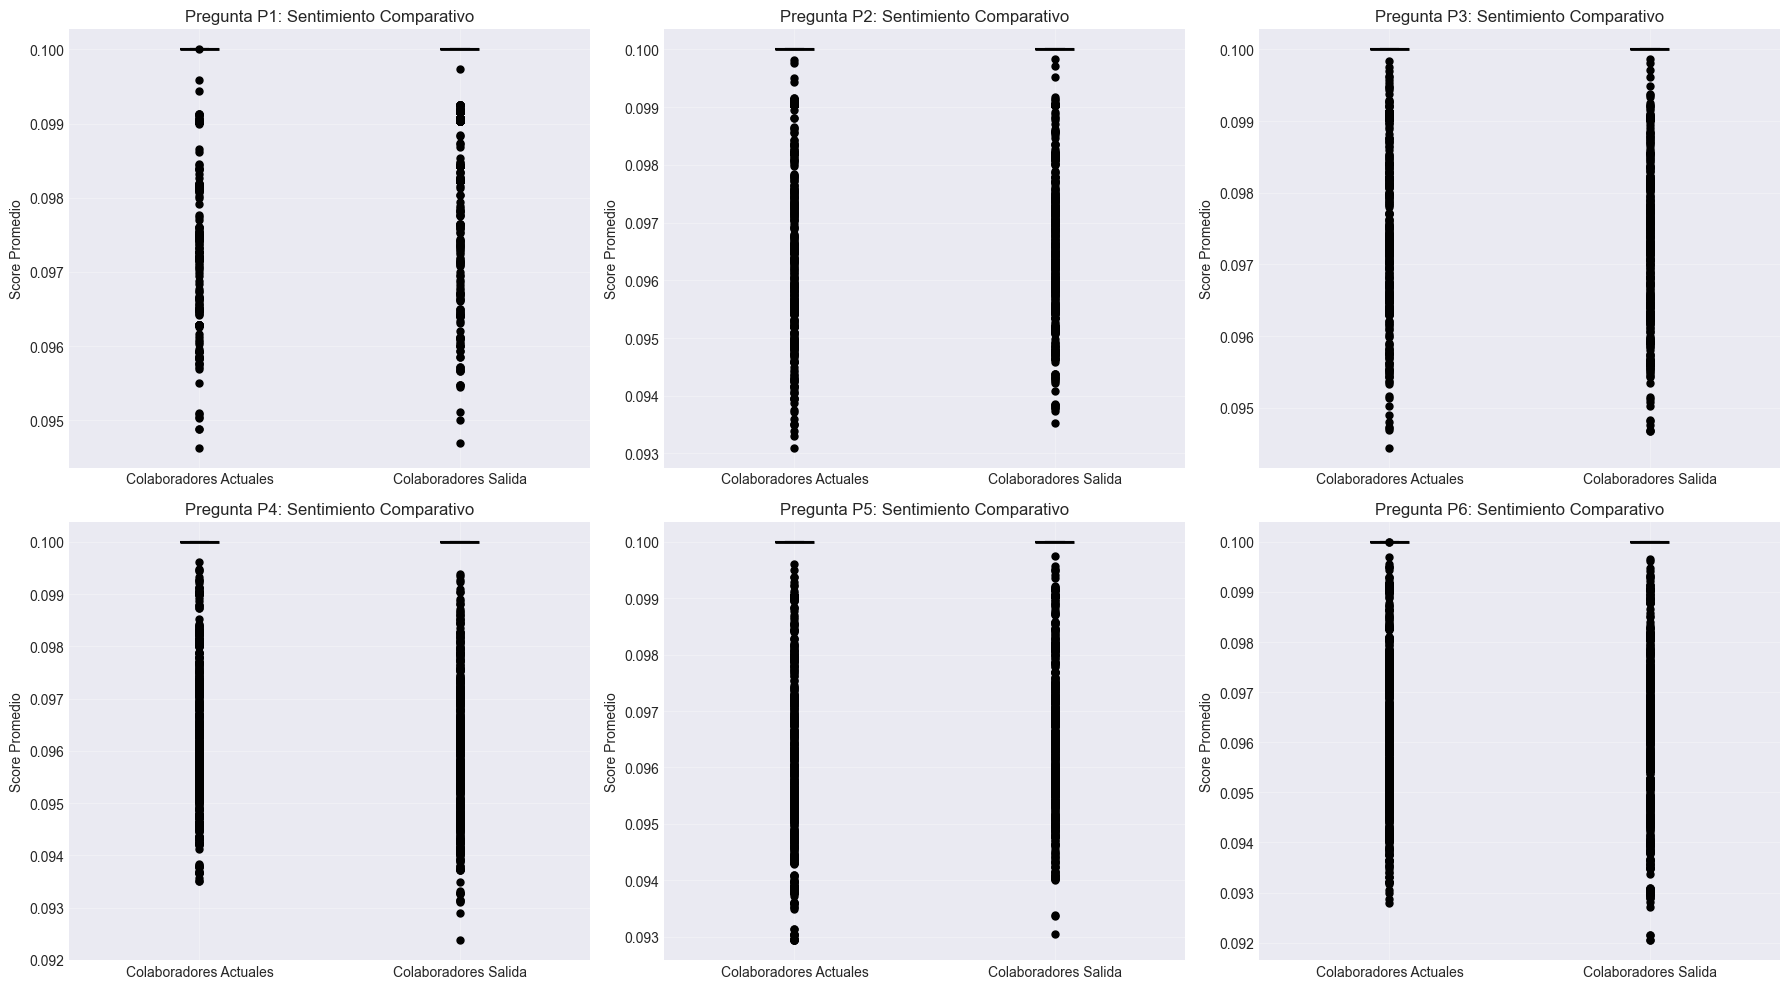

Visualizacion de sentimientos comparativos generada


In [11]:
# Visualizacion: Comparacion de sentimientos entre colaboradores actuales y que salieron
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, p in enumerate(range(1, 7)):
    ax = axes[i]
    
    # Boxplot comparativo
    data_plot = pd.DataFrame({
        'Colaboradores Actuales': df_sentimientos[f'P{p}_actual'],
        'Colaboradores Salida': df_sentimientos[f'P{p}_salida']
    })
    
    data_plot.boxplot(
        ax=ax,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='black', markersize=5, linestyle='none')
        )
    ax.set_title(f'Pregunta P{p}: Sentimiento Comparativo')
    ax.set_ylabel('Score Promedio')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sentimientos_comparativos.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizacion de sentimientos comparativos generada")

In [12]:
# Analisis estadistico de diferencias de sentimiento
print("\n=== PRUEBAS DE HIPOTESIS: DIFERENCIAS DE SENTIMIENTO ===")
print("\nComparacion entre colaboradores actuales y que salieron por pregunta:\n")

for p in range(1, 7):
    actual = df_sentimientos[f'P{p}_actual'].dropna()
    salida = df_sentimientos[f'P{p}_salida'].dropna()
    
    # Test t de Student
    t_stat, p_value = stats.ttest_ind(actual, salida)
    
    # Tamano del efecto (Cohen's d)
    pooled_std = np.sqrt((actual.std()**2 + salida.std()**2) / 2)
    cohens_d = (actual.mean() - salida.mean()) / pooled_std
    
    print(f"Pregunta P{p}:")
    print(f"  Media Actuales: {actual.mean():.4f}")
    print(f"  Media Salida: {salida.mean():.4f}")
    print(f"  Diferencia: {actual.mean() - salida.mean():.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Cohen's d: {cohens_d:.4f}")
    print(f"  Significativo: {'SI' if p_value < 0.05 else 'NO'}")
    print()


=== PRUEBAS DE HIPOTESIS: DIFERENCIAS DE SENTIMIENTO ===

Comparacion entre colaboradores actuales y que salieron por pregunta:

Pregunta P1:
  Media Actuales: 0.0999
  Media Salida: 0.0999
  Diferencia: 0.0000
  t-statistic: 1.8352
  p-value: 0.0665
  Cohen's d: 0.0366
  Significativo: NO

Pregunta P2:
  Media Actuales: 0.0997
  Media Salida: 0.0997
  Diferencia: 0.0000
  t-statistic: 1.0206
  p-value: 0.3075
  Cohen's d: 0.0203
  Significativo: NO

Pregunta P3:
  Media Actuales: 0.0998
  Media Salida: 0.0997
  Diferencia: 0.0000
  t-statistic: 1.9635
  p-value: 0.0496
  Cohen's d: 0.0391
  Significativo: SI

Pregunta P4:
  Media Actuales: 0.0995
  Media Salida: 0.0995
  Diferencia: -0.0000
  t-statistic: -0.9220
  p-value: 0.3565
  Cohen's d: -0.0184
  Significativo: NO

Pregunta P5:
  Media Actuales: 0.0994
  Media Salida: 0.0995
  Diferencia: -0.0001
  t-statistic: -3.6369
  p-value: 0.0003
  Cohen's d: -0.0725
  Significativo: SI

Pregunta P6:
  Media Actuales: 0.0994
  Media Sal

In [13]:
# Identificacion de topics mas polarizados (mayor diferencia entre actuales y salida)
diferencias_topics = []

for p in range(1, 7):
    cols_n = [col for col in topics_n if col.startswith(f'P{p}_n_')]
    cols_v = [col for col in topics_v if col.startswith(f'P{p}_v_')]
    
    for col_n in cols_n:
        topic_num = col_n.split('_')[-1]
        col_v = f'P{p}_v_{topic_num}_{col_n.split("_", 3)[-1]}'
        
        if col_v in df.columns:
            media_n = df[col_n].mean()
            media_v = df[col_v].mean()
            diferencia = abs(media_n - media_v)
            
            diferencias_topics.append({
                'pregunta': f'P{p}',
                'topic': topic_num,
                'descripcion_n': col_n.split('_', 3)[-1].replace('_', ' '),
                'media_actuales': media_n,
                'media_salida': media_v,
                'diferencia_abs': diferencia
            })

df_diferencias = pd.DataFrame(diferencias_topics).sort_values('diferencia_abs', ascending=False)

print("\nTop 15 Topics con Mayor Polarizacion (Diferencia entre Actuales y Salida):")
print(df_diferencias.head(15).to_string(index=False))

KeyError: 'diferencia_abs'

In [14]:
# Visualizacion de topics mas polarizados
top_polarizados = df_diferencias.head(10).copy()

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_polarizados))
width = 0.35

bars1 = ax.bar(x - width/2, top_polarizados['media_actuales'], width, 
               label='Colaboradores Actuales', alpha=0.8)
bars2 = ax.bar(x + width/2, top_polarizados['media_salida'], width, 
               label='Colaboradores Salida', alpha=0.8)

ax.set_xlabel('Topic')
ax.set_ylabel('Score Promedio')
ax.set_title('Top 10 Topics con Mayor Polarizacion: Comparacion Actuales vs Salida')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['pregunta']}-{row['topic']}" for _, row in top_polarizados.iterrows()], 
                    rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('topics_polarizados.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizacion de topics polarizados generada")

NameError: name 'df_diferencias' is not defined

## 4. Correlaciones entre Topics y Variables Organizacionales

Analisis de la relacion entre la probabilidad de topics y caracteristicas organizacionales de los colaboradores.

In [15]:
# Preparacion de variables numericas organizacionales
vars_numericas = ['antiguedad_anois', 'tamano_equipo', 'pct_ocupacion_equipo', 
                  'promedio_grupo_salarial', 'promedio_antiguedad_subordinados_anos']

vars_numericas_disponibles = [v for v in vars_numericas if v in df.columns]
print(f"Variables numericas disponibles para correlacion: {vars_numericas_disponibles}")

Variables numericas disponibles para correlacion: ['antiguedad_anois', 'tamano_equipo', 'pct_ocupacion_equipo', 'promedio_grupo_salarial', 'promedio_antiguedad_subordinados_anos']


In [16]:
# Calculo de matriz de correlacion entre topics agregados y variables organizacionales
# Agregamos topics por pregunta para simplificar el analisis

df_corr = df.copy()

# Agregar topics por pregunta (promedio de todos los subtopics)
for p in range(1, 7):
    cols_p = [col for col in topic_cols if col.startswith(f'P{p}_')]
    df_corr[f'Topic_P{p}_avg'] = df[cols_p].mean(axis=1)

# Seleccionar columnas para correlacion
cols_para_corr = [f'Topic_P{p}_avg' for p in range(1, 7)] + vars_numericas_disponibles
df_corr_subset = df_corr[cols_para_corr].dropna()

# Calcular matriz de correlacion
correlation_matrix = df_corr_subset.corr()

print("Matriz de correlacion calculada")
print(f"Dimensiones: {correlation_matrix.shape}")

Matriz de correlacion calculada
Dimensiones: (11, 11)


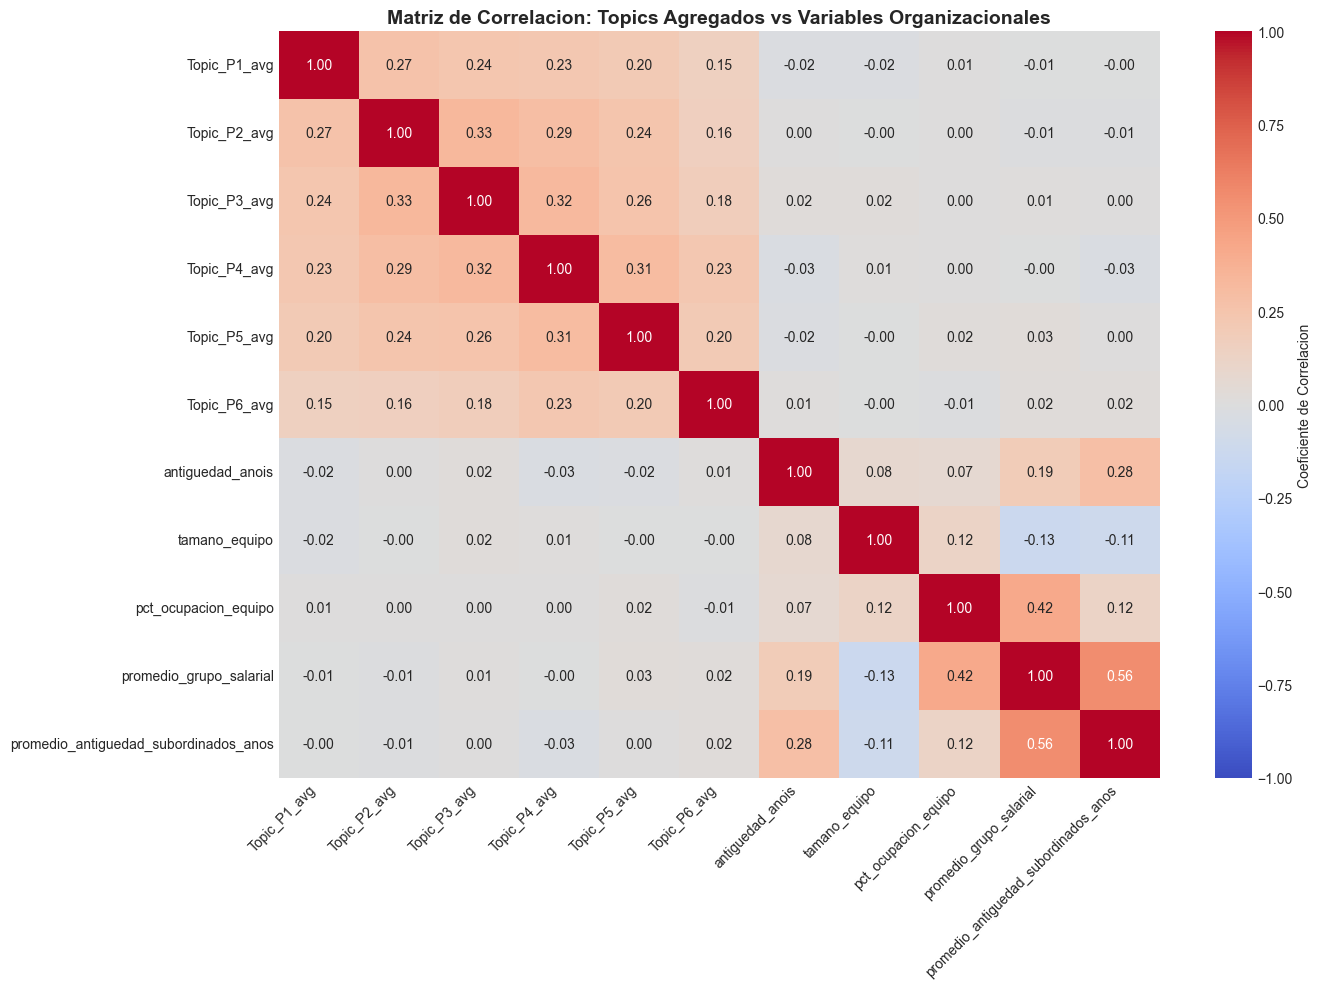

Heatmap de correlaciones generado


In [17]:
# Visualizacion: Heatmap de correlaciones
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Coeficiente de Correlacion'})

ax.set_title('Matriz de Correlacion: Topics Agregados vs Variables Organizacionales', 
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlaciones_topics_org.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap de correlaciones generado")

In [18]:
# Identificacion de correlaciones significativas
# Extraer correlaciones entre topics y variables organizacionales

topic_cols_agg = [f'Topic_P{p}_avg' for p in range(1, 7)]
correlaciones_significativas = []

for topic in topic_cols_agg:
    for var in vars_numericas_disponibles:
        if topic != var:
            corr_val = correlation_matrix.loc[topic, var]
            
            # Test de significancia
            n = df_corr_subset[[topic, var]].dropna().shape[0]
            if n > 2:
                t_stat = corr_val * np.sqrt(n - 2) / np.sqrt(1 - corr_val**2)
                p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
                
                correlaciones_significativas.append({
                    'topic': topic,
                    'variable': var,
                    'correlacion': corr_val,
                    'p_value': p_value,
                    'n': n,
                    'significativo': p_value < 0.05
                })

df_corr_sig = pd.DataFrame(correlaciones_significativas)
df_corr_sig = df_corr_sig.sort_values('correlacion', key=abs, ascending=False)

print("\n=== CORRELACIONES SIGNIFICATIVAS (p < 0.05) ===")
print(df_corr_sig[df_corr_sig['significativo']].to_string(index=False))


=== CORRELACIONES SIGNIFICATIVAS (p < 0.05) ===
Empty DataFrame
Columns: [topic, variable, correlacion, p_value, n, significativo]
Index: []


In [19]:
# Analisis de correlaciones por variable categorica (region, division, etc.)
vars_categoricas = ['region', 'division', 'unidad_de_negocio']
vars_cat_disponibles = [v for v in vars_categoricas if v in df.columns]

print("\n=== CORRELACIONES PROMEDIO POR CATEGORIA ===")

for var_cat in vars_cat_disponibles:
    print(f"\nVariable: {var_cat}")
    
    categorias = df[var_cat].dropna().unique()[:5]  # Top 5 categorias
    
    for categoria in categorias:
        df_cat = df[df[var_cat] == categoria]
        
        if len(df_cat) > 10:  # Minimo 10 observaciones
            print(f"\n  Categoria: {categoria} (n={len(df_cat)})")
            
            for p in range(1, 7):
                cols_p = [col for col in topic_cols if col.startswith(f'P{p}_')]
                avg_topic = df_cat[cols_p].mean(axis=1).mean()
                print(f"    P{p} promedio: {avg_topic:.4f}")


=== CORRELACIONES PROMEDIO POR CATEGORIA ===

Variable: region

  Categoria: MEXICALI (n=234)
    P1 promedio: 0.0999
    P2 promedio: 0.0997
    P3 promedio: 0.0997
    P4 promedio: 0.0996
    P5 promedio: 0.0996
    P6 promedio: 0.0995

  Categoria: CD JUAREZ (n=107)
    P1 promedio: 0.0999
    P2 promedio: 0.0998
    P3 promedio: 0.0999
    P4 promedio: 0.0995
    P5 promedio: 0.0997
    P6 promedio: 0.0996

  Categoria: TOLUCA (n=417)
    P1 promedio: 0.0999
    P2 promedio: 0.0996
    P3 promedio: 0.0998
    P4 promedio: 0.0995
    P5 promedio: 0.0995
    P6 promedio: 0.0994

  Categoria: TEXCOCO (n=106)
    P1 promedio: 0.0999
    P2 promedio: 0.0996
    P3 promedio: 0.0998
    P4 promedio: 0.0995
    P5 promedio: 0.0994
    P6 promedio: 0.0993

  Categoria: PUEBLA (n=197)
    P1 promedio: 0.0999
    P2 promedio: 0.0997
    P3 promedio: 0.0997
    P4 promedio: 0.0994
    P5 promedio: 0.0996
    P6 promedio: 0.0996

Variable: division

  Categoria: DIRECCION DE OPERACIONES DE GC 

## 5. Clustering de Perfiles de Respuesta

Identificacion de grupos homogeneos de colaboradores basados en sus patrones de respuesta a los topics.

In [20]:
# Preparacion de datos para clustering
# Usamos los promedios de topics por pregunta para reducir dimensionalidad

features_clustering = [f'Topic_P{p}_avg' for p in range(1, 7)]
df_clustering = df_corr[features_clustering].dropna()

print(f"Datos para clustering: {df_clustering.shape}")
print(f"\nEstadisticas descriptivas:")
print(df_clustering.describe())

Datos para clustering: (5033, 6)

Estadisticas descriptivas:
       Topic_P1_avg  Topic_P2_avg  Topic_P3_avg  Topic_P4_avg  Topic_P5_avg  \
count   5033.000000   5033.000000   5033.000000   5033.000000   5033.000000   
mean       0.099866      0.099664      0.099746      0.099463      0.099497   
std        0.000550      0.001060      0.000802      0.001368      0.001316   
min        0.095243      0.093315      0.095301      0.093696      0.093556   
25%        0.100000      0.100000      0.100000      0.100000      0.100000   
50%        0.100000      0.100000      0.100000      0.100000      0.100000   
75%        0.100000      0.100000      0.100000      0.100000      0.100000   
max        0.100000      0.100000      0.100000      0.100000      0.100000   

       Topic_P6_avg  
count   5033.000000  
mean       0.099380  
std        0.001467  
min        0.092628  
25%        0.100000  
50%        0.100000  
75%        0.100000  
max        0.100000  


In [21]:
# Estandarizacion de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

print("Datos estandarizados")
print(f"Media: {X_scaled.mean(axis=0)}")
print(f"Desviacion estandar: {X_scaled.std(axis=0)}")

Datos estandarizados
Media: [ 7.85225253e-15 -3.20047761e-15 -7.34119258e-15  4.69624560e-15
 -1.32423820e-15 -6.49413190e-17]
Desviacion estandar: [1. 1. 1. 1. 1. 1.]


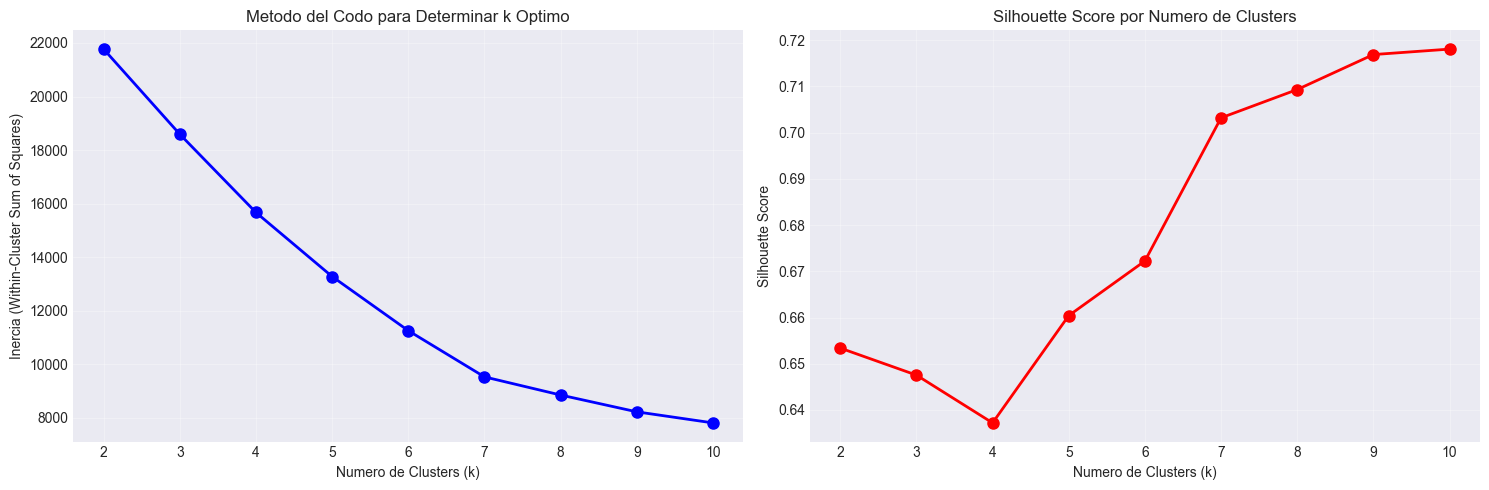


K optimo segun Silhouette Score: 10
Silhouette Score maximo: 0.7180


In [22]:
# Determinacion del numero optimo de clusters - Metodo del codo
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Metodo del codo
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Numero de Clusters (k)')
axes[0].set_ylabel('Inercia (Within-Cluster Sum of Squares)')
axes[0].set_title('Metodo del Codo para Determinar k Optimo')
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por Numero de Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('determinacion_k_optimo.png', dpi=300, bbox_inches='tight')
plt.show()

# Identificar k optimo
k_optimo = k_range[np.argmax(silhouette_scores)]
print(f"\nK optimo segun Silhouette Score: {k_optimo}")
print(f"Silhouette Score maximo: {max(silhouette_scores):.4f}")

In [23]:
# Aplicacion de K-Means con k optimo
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clustering['cluster'] = clusters

# Metricas de calidad del clustering
silhouette_avg = silhouette_score(X_scaled, clusters)
davies_bouldin = davies_bouldin_score(X_scaled, clusters)

print(f"\n=== METRICAS DE CLUSTERING ===")
print(f"Numero de clusters: {k_optimo}")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"\nDistribucion de observaciones por cluster:")
print(df_clustering['cluster'].value_counts().sort_index())


=== METRICAS DE CLUSTERING ===
Numero de clusters: 10
Silhouette Score: 0.7180
Davies-Bouldin Index: 1.2913

Distribucion de observaciones por cluster:
cluster
0    3465
1      74
2     334
3     141
4     106
5      82
6     191
7     165
8     225
9     250
Name: count, dtype: int64


In [24]:
# Reduccion dimensional con PCA para visualizacion
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por las 2 componentes principales: {pca.explained_variance_ratio_.sum():.2%}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

Varianza explicada por las 2 componentes principales: 51.94%
PC1: 36.94%
PC2: 14.99%


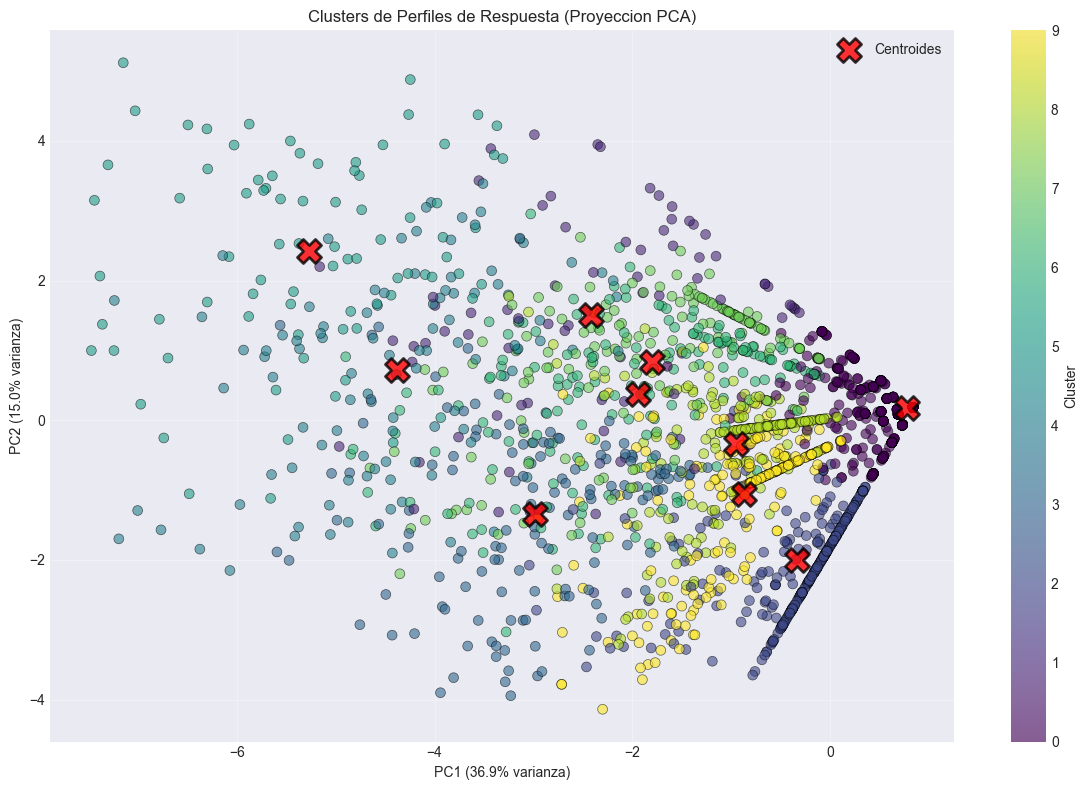

Visualizacion de clusters en espacio PCA generada


In [25]:
# Visualizacion de clusters en espacio PCA
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Centros de clusters en espacio PCA
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=300, 
           alpha=0.8, edgecolors='black', linewidth=2, marker='X', label='Centroides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('Clusters de Perfiles de Respuesta (Proyeccion PCA)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, label='Cluster', ax=ax)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizacion de clusters en espacio PCA generada")


=== CARACTERIZACION DE CLUSTERS ===

Perfiles promedio por cluster:

         Topic_P1_avg  Topic_P2_avg  Topic_P3_avg  Topic_P4_avg  Topic_P5_avg  \
cluster                                                                         
0            0.099978      0.099980      0.099986      0.099973      0.099979   
1            0.097153      0.099686      0.099721      0.098948      0.098761   
2            0.099959      0.099893      0.099932      0.099774      0.099840   
3            0.099791      0.099315      0.099322      0.095954      0.095937   
4            0.099759      0.096037      0.097312      0.097281      0.098010   
5            0.097058      0.096977      0.098200      0.097300      0.098014   
6            0.099864      0.099661      0.096967      0.098932      0.099022   
7            0.099880      0.095961      0.099872      0.098930      0.099205   
8            0.099920      0.099836      0.099847      0.095793      0.099904   
9            0.099933      0.099884    

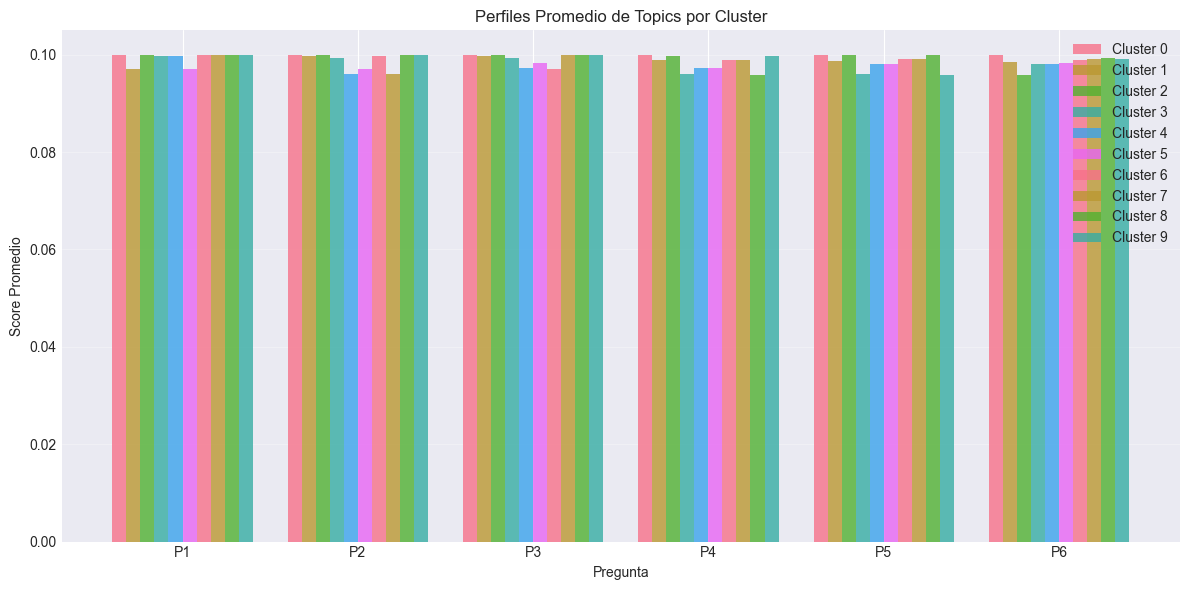

Visualizacion de perfiles de clusters generada


In [26]:
# Caracterizacion de clusters - Perfiles promedio
print("\n=== CARACTERIZACION DE CLUSTERS ===")
print("\nPerfiles promedio por cluster:\n")

cluster_profiles = df_clustering.groupby('cluster')[features_clustering].mean()
print(cluster_profiles)

# Visualizacion de perfiles
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(features_clustering))
width = 0.8 / k_optimo

for i, cluster_id in enumerate(range(k_optimo)):
    values = cluster_profiles.loc[cluster_id].values
    ax.bar(x_pos + i * width, values, width, label=f'Cluster {cluster_id}', alpha=0.8)

ax.set_xlabel('Pregunta')
ax.set_ylabel('Score Promedio')
ax.set_title('Perfiles Promedio de Topics por Cluster')
ax.set_xticks(x_pos + width * (k_optimo - 1) / 2)
ax.set_xticklabels([f'P{p}' for p in range(1, 7)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('perfiles_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizacion de perfiles de clusters generada")

In [27]:
# Interpretacion de clusters - Caracteristicas distintivas
print("\n=== CARACTERISTICAS DISTINTIVAS POR CLUSTER ===")

for cluster_id in range(k_optimo):
    print(f"\nCluster {cluster_id} (n={sum(clusters == cluster_id)}):")
    
    # Valores promedio del cluster
    cluster_mean = cluster_profiles.loc[cluster_id]
    
    # Comparar con el promedio global
    global_mean = df_clustering[features_clustering].mean()
    
    diferencias = cluster_mean - global_mean
    diferencias_sorted = diferencias.abs().sort_values(ascending=False)
    
    print("  Caracteristicas mas distintivas:")
    for feature in diferencias_sorted.head(3).index:
        diff = diferencias[feature]
        direction = "mayor" if diff > 0 else "menor"
        print(f"    - {feature}: {direction} que el promedio ({diff:+.4f})")


=== CARACTERISTICAS DISTINTIVAS POR CLUSTER ===

Cluster 0 (n=3465):
  Caracteristicas mas distintivas:
    - Topic_P6_avg: mayor que el promedio (+0.0006)
    - Topic_P4_avg: mayor que el promedio (+0.0005)
    - Topic_P5_avg: mayor que el promedio (+0.0005)

Cluster 1 (n=74):
  Caracteristicas mas distintivas:
    - Topic_P1_avg: menor que el promedio (-0.0027)
    - Topic_P6_avg: menor que el promedio (-0.0009)
    - Topic_P5_avg: menor que el promedio (-0.0007)

Cluster 2 (n=334):
  Caracteristicas mas distintivas:
    - Topic_P6_avg: menor que el promedio (-0.0036)
    - Topic_P5_avg: mayor que el promedio (+0.0003)
    - Topic_P4_avg: mayor que el promedio (+0.0003)

Cluster 3 (n=141):
  Caracteristicas mas distintivas:
    - Topic_P5_avg: menor que el promedio (-0.0036)
    - Topic_P4_avg: menor que el promedio (-0.0035)
    - Topic_P6_avg: menor que el promedio (-0.0013)

Cluster 4 (n=106):
  Caracteristicas mas distintivas:
    - Topic_P2_avg: menor que el promedio (-0.0036)



=== CLUSTERING JERARQUICO ===


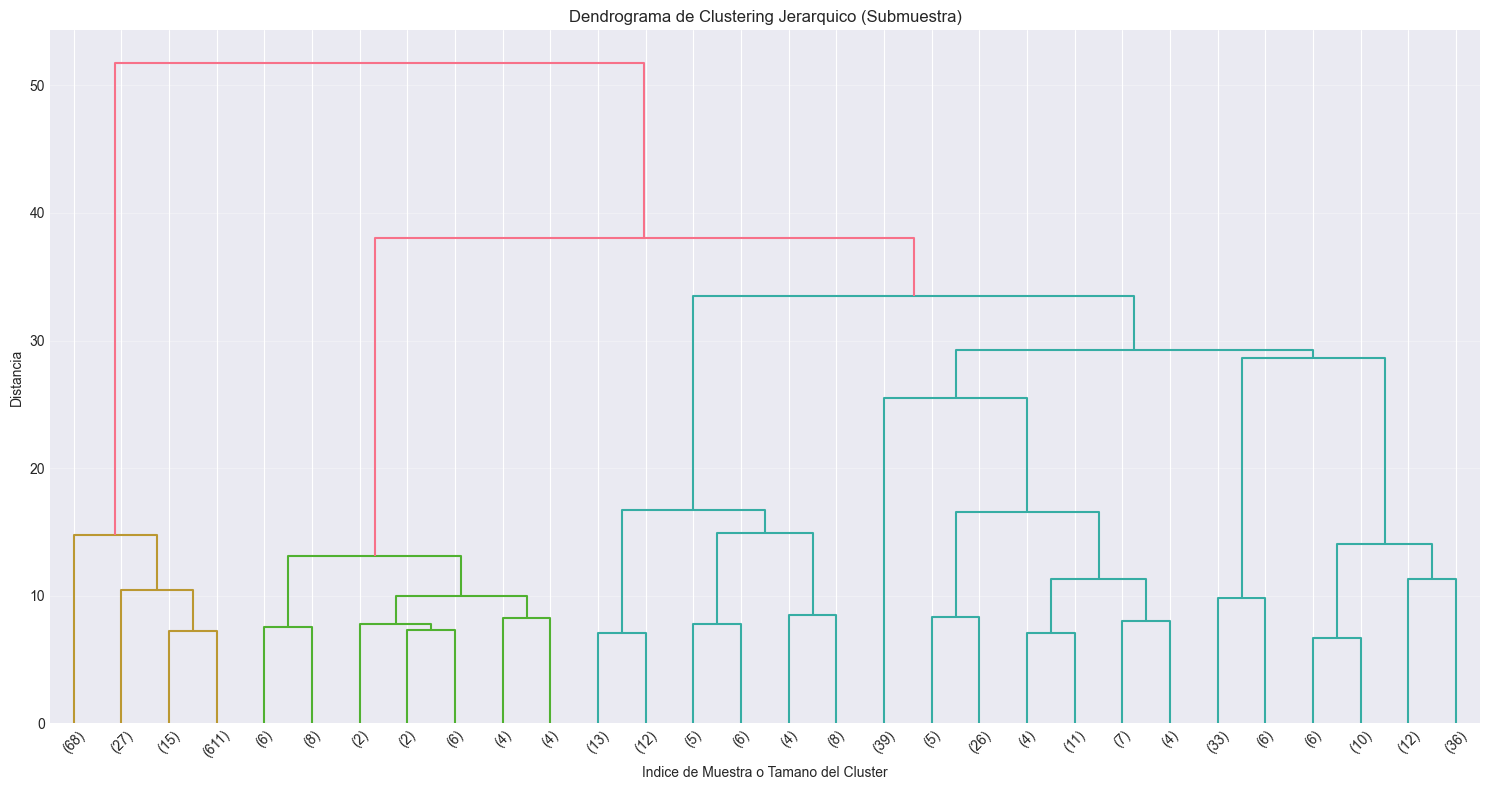

Dendrograma generado


In [28]:
# Clustering jerarquico como alternativa
print("\n=== CLUSTERING JERARQUICO ===")

# Calcular linkage
linkage_matrix = linkage(X_scaled[:1000], method='ward')  # Usamos submuestra para eficiencia

# Visualizar dendrograma
fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30)
ax.set_xlabel('Indice de Muestra o Tamano del Cluster')
ax.set_ylabel('Distancia')
ax.set_title('Dendrograma de Clustering Jerarquico (Submuestra)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dendrograma_jerarquico.png', dpi=300, bbox_inches='tight')
plt.show()

print("Dendrograma generado")

## 6. Grafos de Relaciones entre Variables

Construccion de redes que muestran las relaciones entre topics, variables organizacionales y clusters identificados.

In [29]:
# Crear grafo de correlaciones significativas
G_corr = nx.Graph()

# Agregar nodos
for topic in topic_cols_agg:
    G_corr.add_node(topic, node_type='topic')

for var in vars_numericas_disponibles:
    G_corr.add_node(var, node_type='org_var')

# Agregar aristas (correlaciones significativas)
threshold_corr = 0.3  # Umbral de correlacion minima

for _, row in df_corr_sig.iterrows():
    if abs(row['correlacion']) >= threshold_corr and row['significativo']:
        G_corr.add_edge(row['topic'], row['variable'], 
                       weight=abs(row['correlacion']),
                       sign='positive' if row['correlacion'] > 0 else 'negative')

print(f"\n=== GRAFO DE CORRELACIONES ===")
print(f"Numero de nodos: {G_corr.number_of_nodes()}")
print(f"Numero de aristas: {G_corr.number_of_edges()}")
print(f"Densidad: {nx.density(G_corr):.4f}")


=== GRAFO DE CORRELACIONES ===
Numero de nodos: 11
Numero de aristas: 0
Densidad: 0.0000


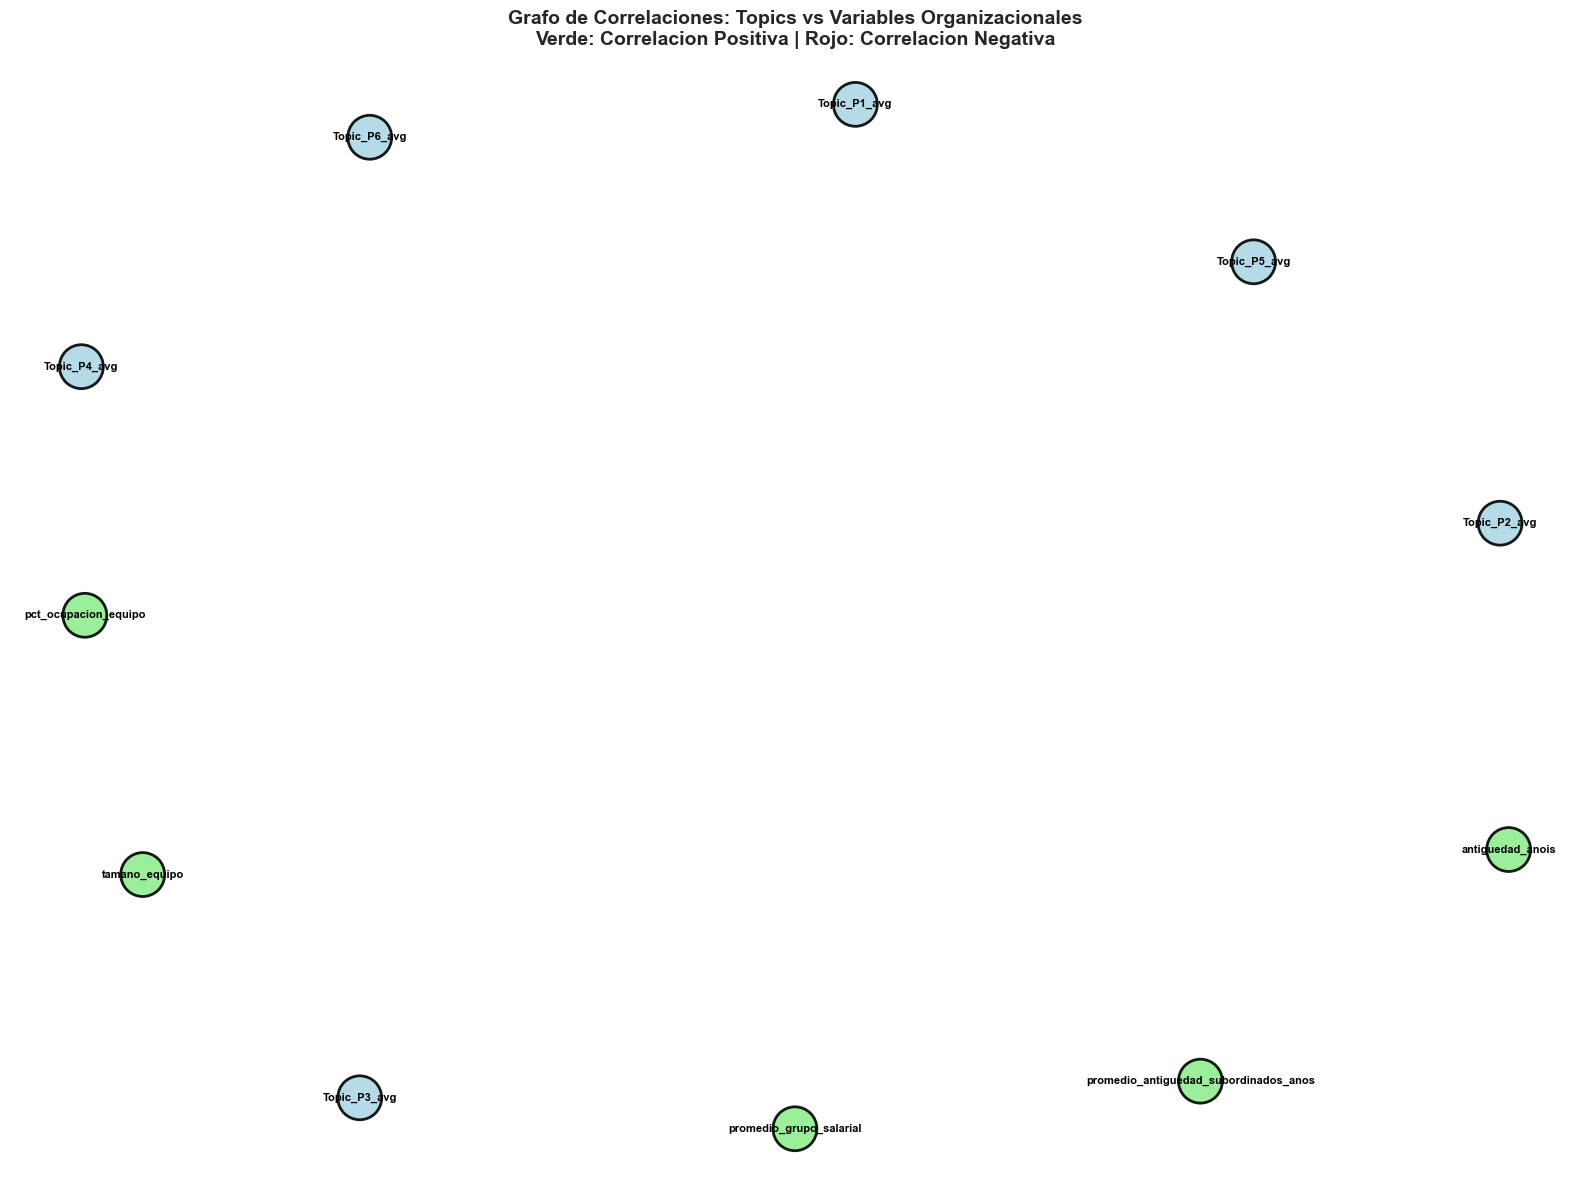

Grafo de correlaciones generado


In [30]:
# Visualizacion del grafo de correlaciones
fig, ax = plt.subplots(figsize=(16, 12))

# Layout
pos = nx.spring_layout(G_corr, k=2, iterations=50, seed=42)

# Colores de nodos segun tipo
node_colors = ['lightblue' if G_corr.nodes[node]['node_type'] == 'topic' else 'lightgreen' 
               for node in G_corr.nodes()]

# Dibujar nodos
nx.draw_networkx_nodes(G_corr, pos, node_color=node_colors, node_size=1000, 
                       alpha=0.9, edgecolors='black', linewidths=2, ax=ax)

# Dibujar aristas
edges_positive = [(u, v) for u, v, d in G_corr.edges(data=True) if d['sign'] == 'positive']
edges_negative = [(u, v) for u, v, d in G_corr.edges(data=True) if d['sign'] == 'negative']

# Grosor proporcional al peso
widths_positive = [G_corr[u][v]['weight'] * 5 for u, v in edges_positive]
widths_negative = [G_corr[u][v]['weight'] * 5 for u, v in edges_negative]

nx.draw_networkx_edges(G_corr, pos, edgelist=edges_positive, width=widths_positive,
                       edge_color='green', alpha=0.5, ax=ax, style='solid')
nx.draw_networkx_edges(G_corr, pos, edgelist=edges_negative, width=widths_negative,
                       edge_color='red', alpha=0.5, ax=ax, style='dashed')

# Etiquetas
nx.draw_networkx_labels(G_corr, pos, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Grafo de Correlaciones: Topics vs Variables Organizacionales\n'
             'Verde: Correlacion Positiva | Rojo: Correlacion Negativa', 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('grafo_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafo de correlaciones generado")

In [31]:
# Metricas de centralidad del grafo
print("\n=== METRICAS DE CENTRALIDAD ===")

# Grado de centralidad
degree_centrality = nx.degree_centrality(G_corr)
print("\nTop 5 nodos por Grado de Centralidad:")
for node, centrality in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {centrality:.4f}")

# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G_corr)
print("\nTop 5 nodos por Betweenness Centralidad:")
for node, centrality in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {centrality:.4f}")

# Closeness centrality
if nx.is_connected(G_corr):
    closeness_centrality = nx.closeness_centrality(G_corr)
    print("\nTop 5 nodos por Closeness Centralidad:")
    for node, centrality in sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {node}: {centrality:.4f}")
else:
    print("\nEl grafo no es conexo, Closeness Centrality no aplicable")


=== METRICAS DE CENTRALIDAD ===

Top 5 nodos por Grado de Centralidad:
  Topic_P1_avg: 0.0000
  Topic_P2_avg: 0.0000
  Topic_P3_avg: 0.0000
  Topic_P4_avg: 0.0000
  Topic_P5_avg: 0.0000

Top 5 nodos por Betweenness Centralidad:
  Topic_P1_avg: 0.0000
  Topic_P2_avg: 0.0000
  Topic_P3_avg: 0.0000
  Topic_P4_avg: 0.0000
  Topic_P5_avg: 0.0000

El grafo no es conexo, Closeness Centrality no aplicable
